In [1]:
import pandas as pd
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm import tqdm
import glob
import warnings
import csv
from collections import OrderedDict
from sklearn.model_selection import train_test_split

print(os.getcwd())


/home/roboracer/mammolesionoscopy


In [2]:
warnings.filterwarnings('ignore')

# Device Configuration
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU found. Using CPU.")

Using GPU: NVIDIA GeForce RTX 5070


In [3]:
# --- Hyperparameters & Device Config ---
IMAGE_SIZE = 224
RANDOM_SEED = 42

# Set random seed for reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [ ]:
# Run the rebuild
import importlib
from helpers import dataset as dshlep
importlib.reload(dshlep)

master_map = dshlep.build_master_dataset()

Building metadata lookup from: ./data/csv/dicom_info.csv


Building lookup map: 100%|██████████| 9671/9671 [00:00<00:00, 40736.20it/s]


Metadata lookup map built. Found 6424 unique composite keys.


Processing mass_case_description_train_set.csv: 1318it [00:16, 81.03it/s]
Processing mass_case_description_test_set.csv: 378it [00:04, 80.47it/s]
Processing calc_case_description_train_set.csv: 1546it [00:19, 79.52it/s] 
Processing calc_case_description_test_set.csv: 326it [00:00, 2696.76it/s]


DATASET BUILD SUMMARY
Master list saved to: ./data/modified/master_dataset.csv
Valid pairs found: 3445
Benign cases without masks (n/a): 193
Malignant cases skipped (no mask): 127


In [4]:
master_ds = pd.read_csv("./data/modified/master_dataset.csv")

# Get unique list of patient IDs and split them for training and validation
master_ds = master_ds[master_ds['mask_status'] == "valid"].reset_index(drop=True)

print(f"Filtered dataset has {len(master_ds)} samples.")


Filtered dataset has 3252 samples.


In [5]:
from helpers import dataset
import importlib
importlib.reload(dataset)

# Create datasets with the new multi-task dataset class
dataset_mt = dataset.MammographyDataset(master_ds, image_size=IMAGE_SIZE)

In [6]:
# from the train dataset extract all images into a tensor, all masks into another tensor, and all labels for each label type into another tensor

imgs = []
masks = []
pathology_labels = []
abnormality_labels = []
birad_labels = []

for i in tqdm(range(len(dataset_mt)), desc="Extracting data from training dataset"):
    row = dataset_mt[i]
    imgs.append(row["image"])
    masks.append(row["mask"])
    pathology_labels.append(row["pathology_label"])
    abnormality_labels.append(row["abnormality_label"])
    birad_labels.append(row["birad_label"])

# Move everything to CPU first to avoid CUDA kernel incompatibility issues
imgs = torch.stack([img.detach().cpu() for img in imgs])
masks = torch.stack([mask.detach().cpu() for mask in masks])

# Labels are scalar tensors, so stack (not torch.tensor(list_of_tensors))
pathology_labels = torch.stack([lbl.detach().cpu() for lbl in pathology_labels]).long()
abnormality_labels = torch.stack([lbl.detach().cpu() for lbl in abnormality_labels]).long()
birad_labels = torch.stack([lbl.detach().cpu() for lbl in birad_labels]).long()

# make all 2s into 0s in pathology_labels
pathology_labels = pathology_labels.clone()
pathology_labels[pathology_labels == 2] = 0

Extracting data from training dataset: 100%|██████████| 3252/3252 [00:31<00:00, 103.26it/s]


[2494  666 2924]


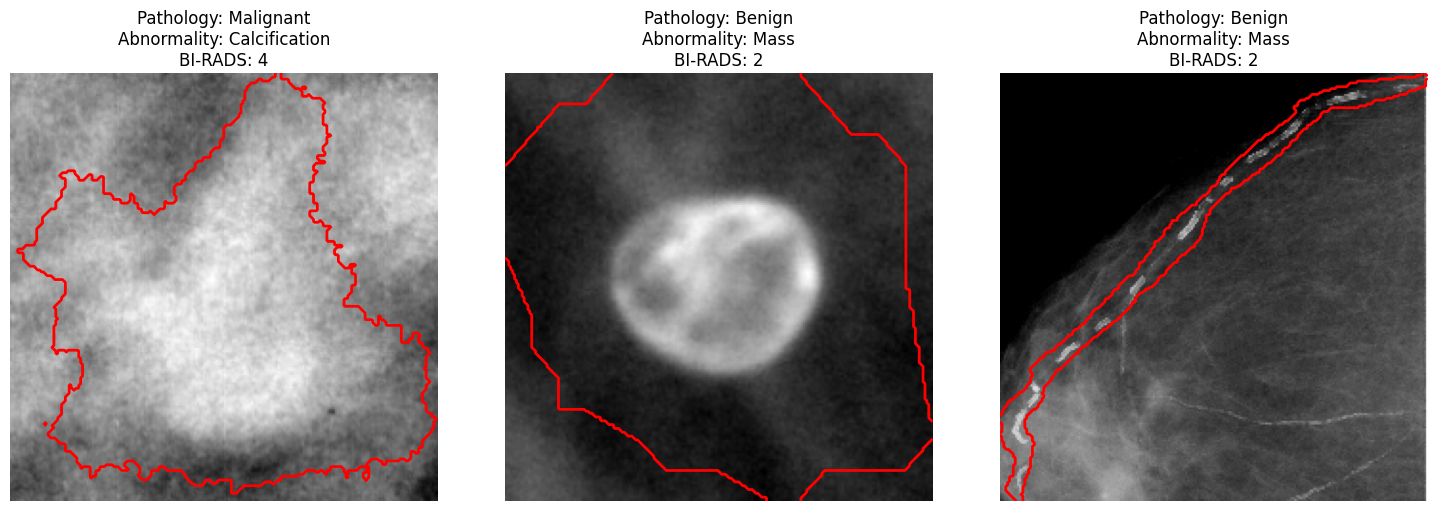

In [115]:
from skimage import measure

# Visualize a set of three images along with their three labels (pathology, abnormality, birad)

# Define label mappings (update as needed for your dataset)
pathology_map = {0: "Benign", 1: "Malignant"}
abnormality_map = {0: "Mass", 1: "Calcification"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
indices = np.random.choice(len(imgs), 3, replace=False)
print(indices)

indices=[5, 3110, 2060]

for ax, idx in zip(axes, indices):
    img = imgs[idx].squeeze().numpy()
    mask = masks[idx].squeeze().numpy()
    pathology = pathology_labels[idx].item()
    abnormality = abnormality_labels[idx].item()
    birad = birad_labels[idx].item()

    # Show image
    ax.imshow(img, cmap="gray")
    # Overlay segmentation boundary in red
    contours = measure.find_contours(mask, 0.5)
    for contour in contours:
        ax.plot(contour[:, 1], contour[:, 0], color="red", linewidth=2)

    ax.axis("off")
    ax.set_title(
        f"Pathology: {pathology_map.get(pathology, pathology)}\n"
        f"Abnormality: {abnormality_map.get(abnormality, abnormality)}\n"
        f"BI-RADS: {birad}"
    )

plt.tight_layout()
plt.show()

Creating pie charts...


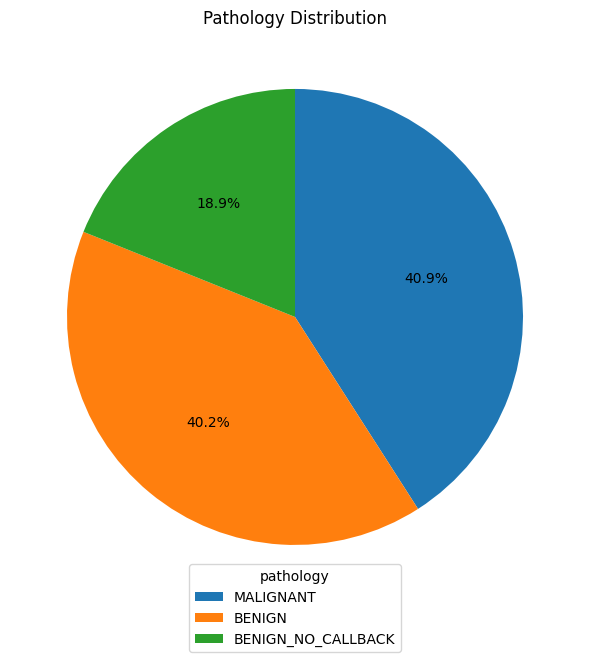

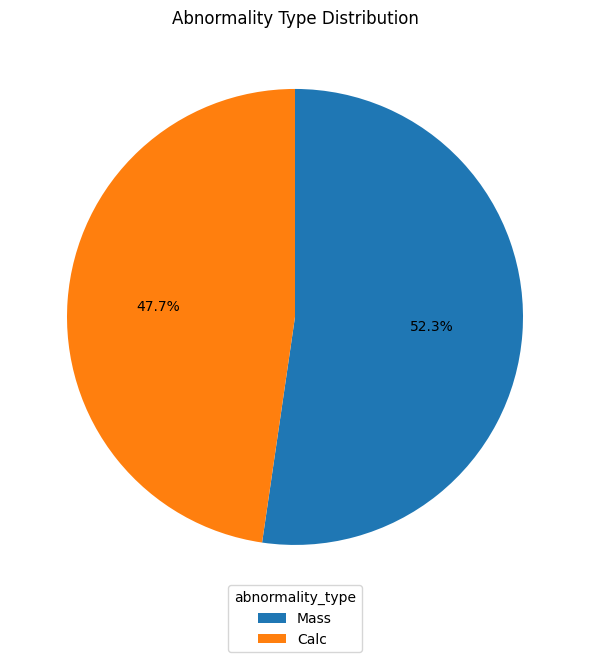

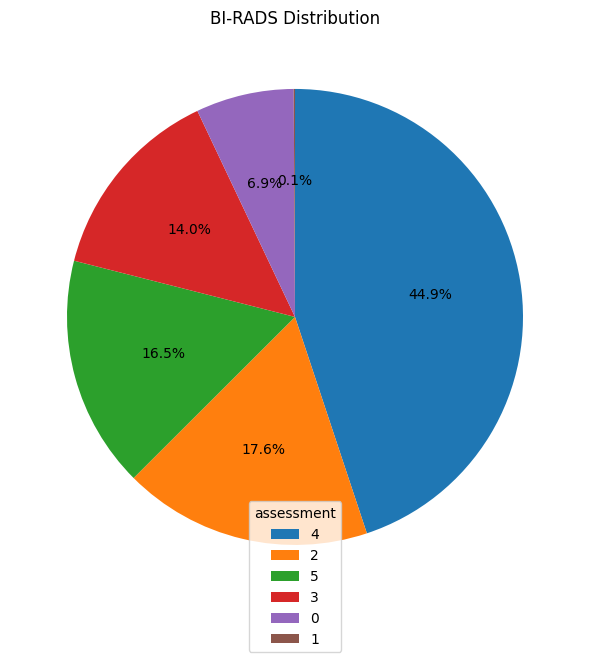

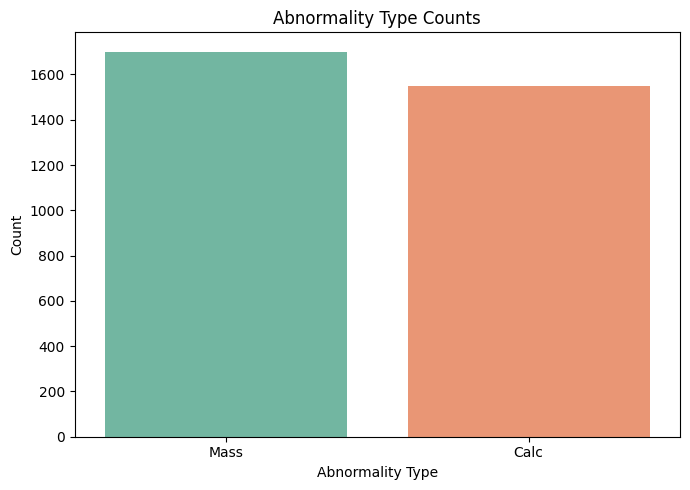

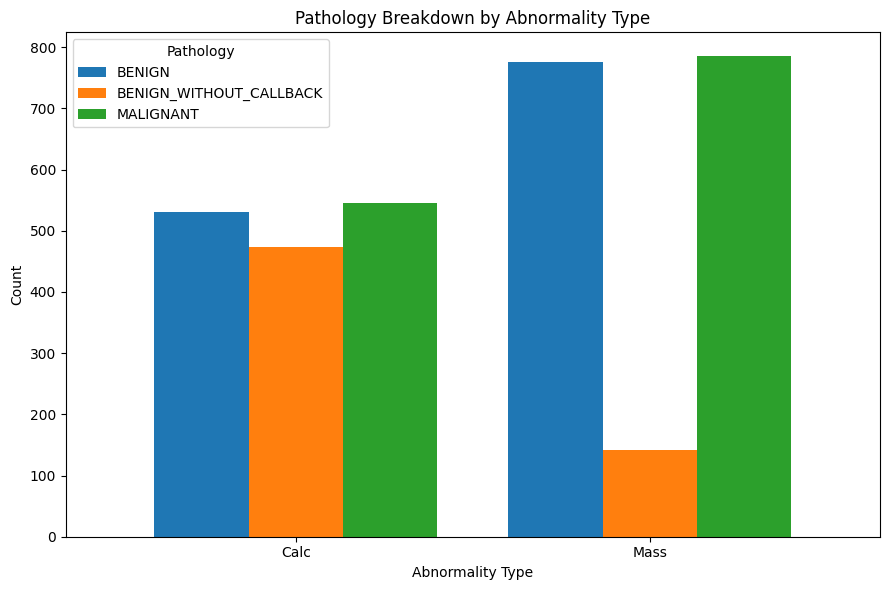

In [47]:
from matplotlib import pyplot as plt
# 1) Pie charts for the three labels: pathology, abnormality_type, and assessment (BI-RADS)
print("Creating pie charts...")

label_specs = [
    ("pathology", "Pathology Distribution"),
    ("abnormality_type", "Abnormality Type Distribution"),
    ("assessment", "BI-RADS Distribution"),
]

for col, title in label_specs:
    counts = master_ds[col].value_counts()

    if col == "pathology":
        counts = counts.rename(
            index=lambda x: "BENIGN_NO_CALLBACK"
            if str(x).lower() == "benign_without_callback"
            else x
        )

    plt.figure(figsize=(6, 8))
    wedges, _, _ = plt.pie(
        counts.values,
        labels=None,              # no labels on slices
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False
    )
    plt.legend(
        wedges,
        counts.index.astype(str),
        title=col,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1)
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()


# 2) Bar chart for abnormality_type counts
plt.figure(figsize=(7, 5))
abn_counts = master_ds["abnormality_type"].value_counts()
sns.barplot(x=abn_counts.index, y=abn_counts.values, palette="Set2")
plt.title("Abnormality Type Counts")
plt.xlabel("Abnormality Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# 3) Grouped bars: pathology breakdown within each abnormality_type
breakdown = pd.crosstab(master_ds["abnormality_type"], master_ds["pathology"])

ax = breakdown.plot(kind="bar", figsize=(9, 6), width=0.8)
ax.set_title("Pathology Breakdown by Abnormality Type")
ax.set_xlabel("Abnormality Type")
ax.set_ylabel("Count")
ax.legend(title="Pathology")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models

# set tensorflow to always use CPU to avoid CUDA kernel incompatibility issues
tf.config.set_visible_devices([], 'GPU')


BATCH_SIZE = 32
NUM_EPOCHS = 20

# Convert channels-first (N, C, H, W) -> channels-last (N, H, W, C)
X = imgs.permute(0, 2, 3, 1).cpu().numpy()
y = abnormality_labels.cpu().numpy().reshape(-1, 1)

# Build shallow CNN
shalllow2lyr = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

shalllow2lyr.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", "precision", "recall", "f1_score"])
shalllow2lyr.summary()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, shuffle=True, random_state=RANDOM_SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.4, shuffle=True, random_state=RANDOM_SEED
)

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

history = shalllow2lyr.fit(
    X_train, y_train,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    shuffle=True
)




Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,619,809 (6.18 MB)

 Trainable params: 1,619,809 (6.18 MB)

 Non-trainable params: 0 (0.00 B)

Training set: (2276, 224, 224, 1), (2276, 1)
Validation set: (585, 224, 224, 1), (585, 1)
Test set: (391, 224, 224, 1), (391, 1)
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 225ms/step - accuracy: 0.6837 - f1_score: 0.6794 - loss: 0.6371 - precision: 0.6669 - recall: 0.7694 - val_accuracy: 0.7897 - val_f1_score: 0.7115 - val_loss: 0.4857 - val_precision: 0.7732 - val_recall: 0.8762
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 214ms/step - accuracy: 0.7786 - f1_score: 0.6794 - loss: 0.4874 - precision: 0.7692 - recall: 0.8138 - val_accuracy: 0.7333 - val_f1_score: 0.7115 - val_loss: 0.5251 - val_precision: 0.7930 - val_recall: 0.6997
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 214ms/step - accuracy: 0.7988 - f1_score: 0.6794 - loss: 0.4451 - precision: 0.7973 - recall: 0.8164 - val_accuracy: 0.8120 - val_f1_score: 0.7115 - val_loss: 0.4283 - val_precision: 0.8277 - val_recall: 0.8328
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 215ms/step - accuracy: 0.8339 - f1_score: 0.6794 - loss: 0.4055 - prec

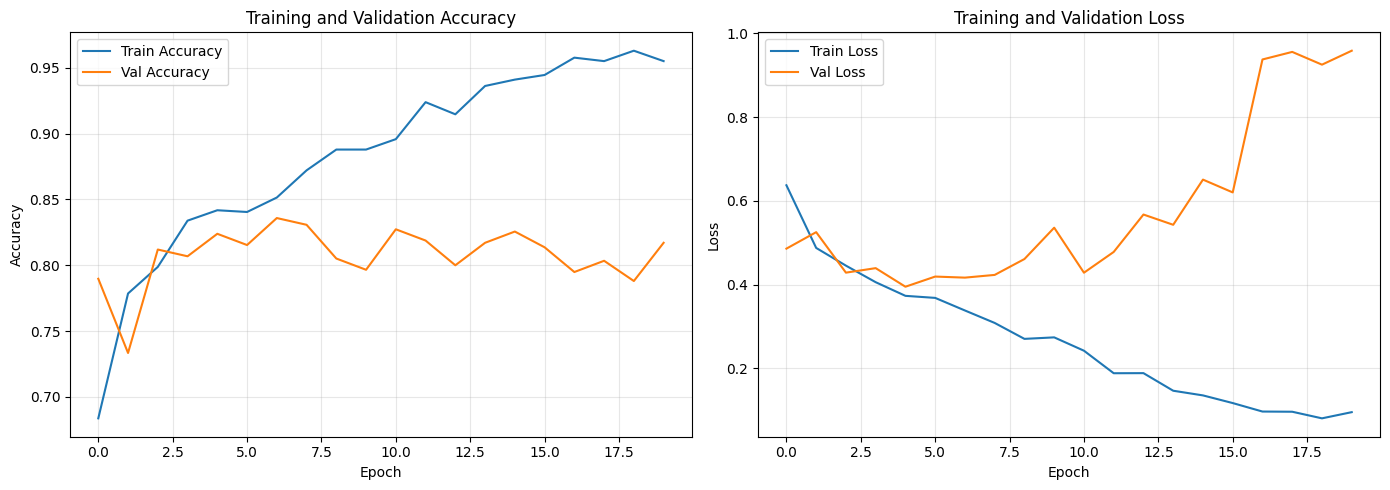

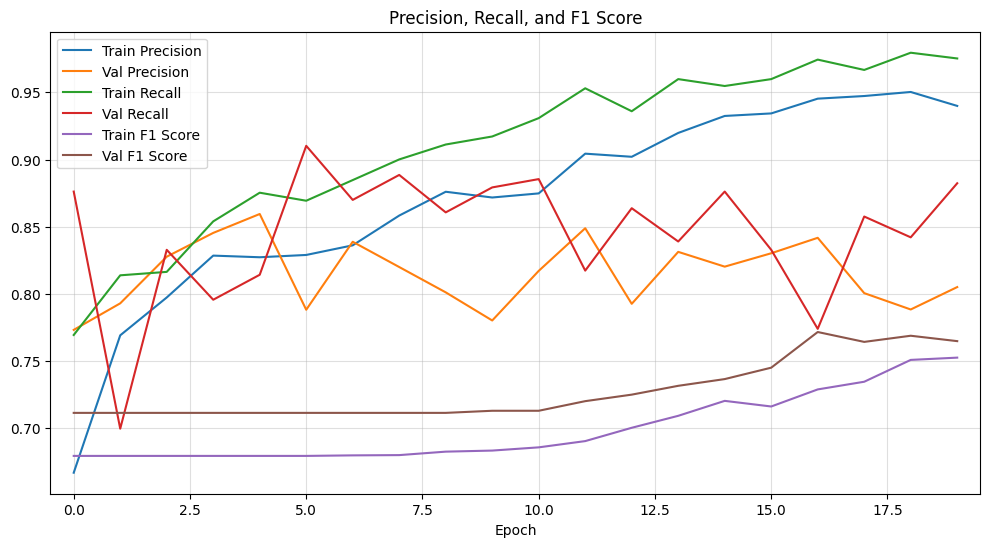

In [23]:
# Visualize training and validation accuracy and loss from Keras history

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(history.history["precision"], label="Train Precision")
plt.plot(history.history["val_precision"], label="Val Precision")
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Val Recall")
plt.plot(history.history["f1_score"], label="Train F1 Score")
plt.plot(history.history["val_f1_score"], label="Val F1 Score")
plt.title("Precision, Recall, and F1 Score")
plt.xlabel("Epoch")
plt.xlim([-.5,19.5])
plt.grid(alpha=0.4)
plt.legend()


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


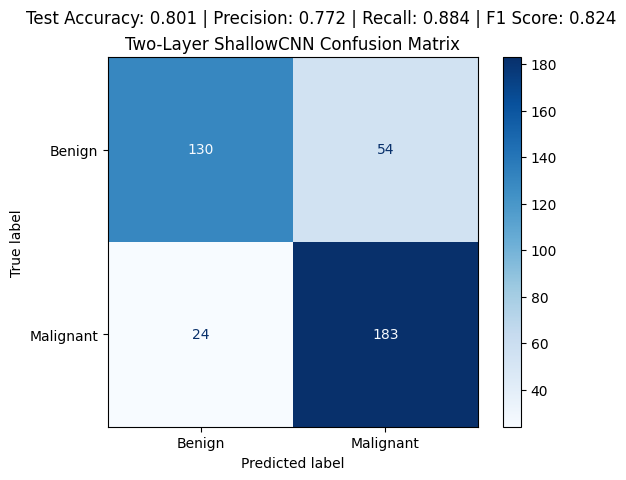

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
y_pred_prob = shalllow2lyr.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
# also display the accuracy, precision, recall, and f1 score in the subtitle
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
plt.title("Two-Layer ShallowCNN Confusion Matrix")
plt.suptitle(f"Test Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1 Score: {f1:.3f}")
plt.show()

In [ ]:
np.bincount(y_birad)

array([ 226,    3,  573,  455, 1460,  535])

In [30]:
# BI-RADS multi-class training with class weighting

BATCH_SIZE = 16
NUM_EPOCHS = 20
NUM_CLASSES = 6  # BI-RADS 0..5

# Convert channels-first (N, C, H, W) -> channels-last (N, H, W, C)
X_birad = imgs.permute(0, 2, 3, 1).cpu().numpy().astype("float32")
y_birad = birad_labels.cpu().numpy().astype("int32")
y_birad[y_birad == 1] = 0 

print("BI-RADS labels present:", np.unique(y_birad))



X_train, X_temp, y_train, y_temp = train_test_split(
    X_birad,
    y_birad,
    test_size=0.3,
    shuffle=True,
    stratify=y_birad,
    random_state=RANDOM_SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.4,
    shuffle=True,
    stratify=y_temp,
    random_state=RANDOM_SEED
)

print(f"Training set:   {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set:       {X_test.shape}, {y_test.shape}")

# Class weights (inverse-frequency on TRAIN set)
counts = np.bincount(y_train, minlength=NUM_CLASSES)
present_classes = np.where(counts > 0)[0]
class_weights = {
    int(c): float(len(y_train) / (len(present_classes) * counts[c]))
    for c in present_classes
}
print("Class counts (train):", counts)
print("Class weights:", class_weights)

# Build shallow CNN for multi-class output
birad_cnn = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

birad_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
birad_cnn.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True
    )
]

history_birad = birad_cnn.fit(
    X_train, y_train,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_acc = birad_cnn.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


BI-RADS labels present: [0 2 3 4 5]
Training set:   (2276, 224, 224, 1), (2276,)
Validation set: (585, 224, 224, 1), (585,)
Test set:       (391, 224, 224, 1), (391,)
Class counts (train): [ 160    0  401  319 1022  374]
Class weights: {0: 2.845, 2: 1.1351620947630923, 3: 1.4269592476489028, 4: 0.44540117416829744, 5: 1.2171122994652406}


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,620,134 (6.18 MB)

 Trainable params: 1,620,134 (6.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - accuracy: 0.2337 - loss: 1.6742 - val_accuracy: 0.2838 - val_loss: 1.5753
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.2816 - loss: 1.5422 - val_accuracy: 0.4137 - val_loss: 1.4634
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.3291 - loss: 1.4414 - val_accuracy: 0.3350 - val_loss: 1.4604
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.3647 - loss: 1.3609 - val_accuracy: 0.2855 - val_loss: 1.5047
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.4284 - loss: 1.2201 - val_accuracy: 0.3368 - val_loss: 1.5426
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.4938 - loss: 1.0628 - val_accuracy: 0.3282 - val_loss: 1.6402
Epoch 7/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.5703 - loss: 0.9007 - val_accuracy: 0.3744 - val_loss: 1.6507
Epoch 8/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.6318 - loss: 0

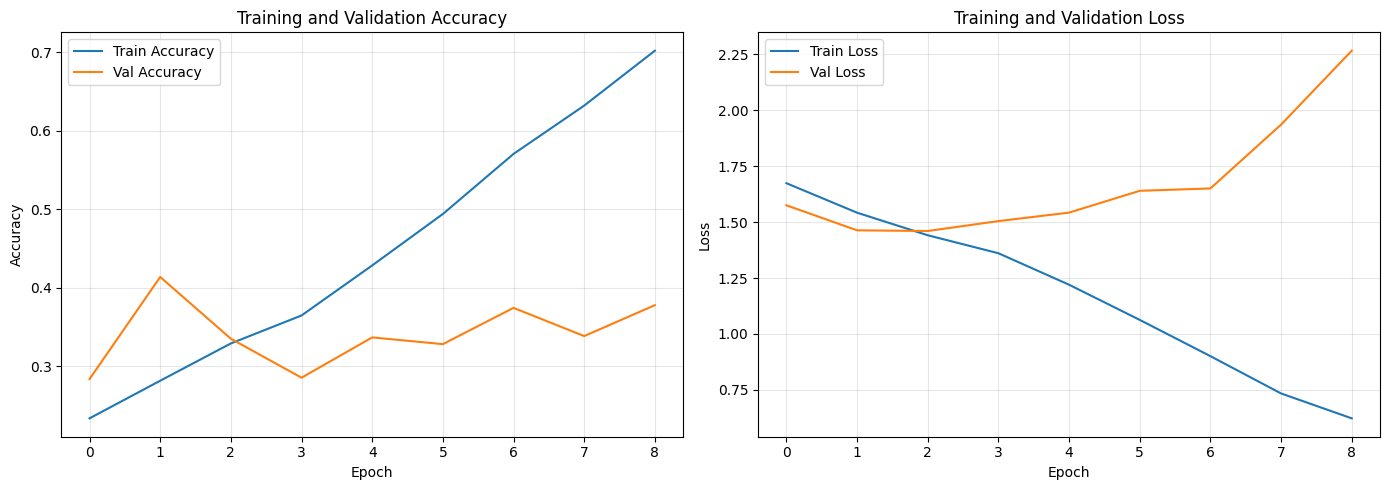

In [43]:
# Visualize training and validation accuracy and loss from Keras history

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_birad.history["accuracy"], label="Train Accuracy")
plt.plot(history_birad.history["val_accuracy"], label="Val Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_birad.history["loss"], label="Train Loss")
plt.plot(history_birad.history["val_loss"], label="Val Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

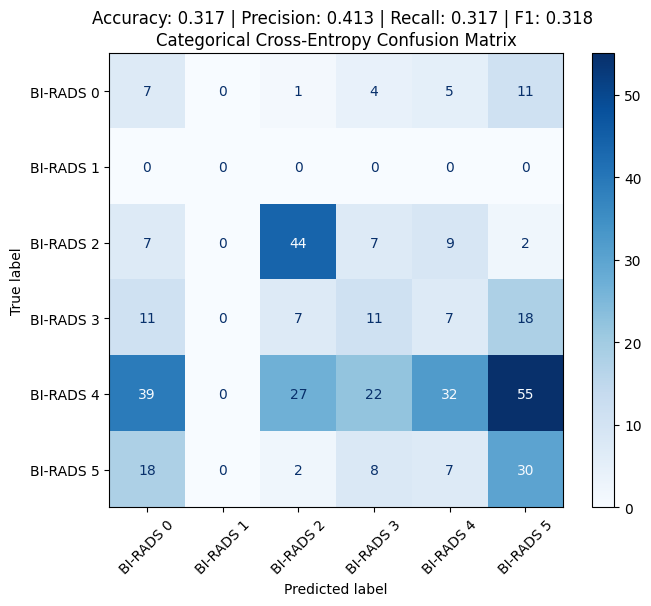

<Figure size 640x480 with 0 Axes>

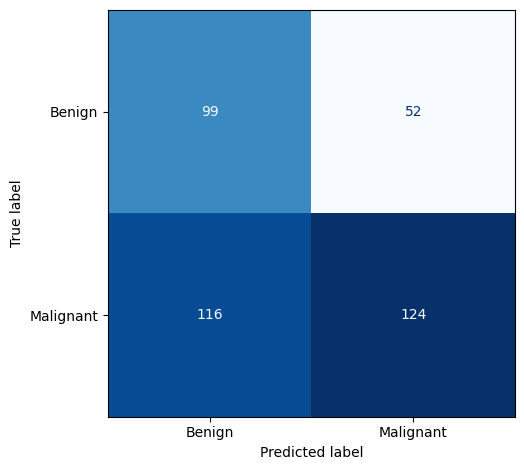

In [88]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
# Predictions for sparse-categorical BI-RADS CNN
y_pred_prob = birad_cnn.predict(X_test, verbose=0)
y_pred_cls = np.argmax(y_pred_prob, axis=1).astype(int)

# True classes (supports sparse labels; handles one-hot if present)
y_true_arr = np.asarray(y_test)
if y_true_arr.ndim > 1 and y_true_arr.shape[1] > 1:
    y_true_cls = np.argmax(y_true_arr, axis=1).astype(int)
else:
    y_true_cls = y_true_arr.reshape(-1).astype(int)

y_true_cls = np.clip(y_true_cls, 0, 5)
y_pred_cls = np.clip(y_pred_cls, 0, 5)

# Multi-class confusion matrix with BI-RADS 0..5 included
labels = [0, 1, 2, 3, 4, 5]
cm = confusion_matrix(y_true_cls, y_pred_cls, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[f"BI-RADS {i}" for i in labels]
)
disp.plot(cmap="Blues", ax=ax, colorbar=True, xticks_rotation=45)
acc = accuracy_score(y_true_cls, y_pred_cls)
prec = precision_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
rec = recall_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
f1 = f1_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)

ax.set_title("Categorical Cross-Entropy Confusion Matrix")
plt.suptitle(f"Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
plt.tight_layout()
plt.show()

# Binary confusion matrix: BI-RADS 0-3 = benign, 4-5 = malignant
y_true_bin = (y_true_cls >= 4).astype(int)
y_pred_bin = (y_pred_cls >= 4).astype(int)

cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Blues", colorbar=False)

ax.set_title("Benign vs Malignant Confusion Matrix")
plt.tight_layout()
plt.show()

In [44]:
# BI-RADS continuous-output training (regression-style)

BATCH_SIZE = 16
NUM_EPOCHS = 20
MAX_BIRADS = 6.0  # output range [0, 6]

# Convert channels-first (N, C, H, W) -> channels-last (N, H, W, C)
X_birad = imgs.permute(0, 2, 3, 1).cpu().numpy().astype("float32")
y_birad = birad_labels.cpu().numpy().astype("float32")

# keep your previous remap if needed
y_birad[y_birad == 1] = 0
y_birad = np.clip(y_birad, 0, MAX_BIRADS)

print("BI-RADS labels present:", np.unique(y_birad))

X_train, X_temp, y_train, y_temp = train_test_split(
    X_birad, y_birad, test_size=0.3, shuffle=True, stratify=y_birad.astype(int), random_state=RANDOM_SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.4, shuffle=True, stratify=y_temp.astype(int), random_state=RANDOM_SEED
)

print(f"Training set:   {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set:       {X_test.shape}, {y_test.shape}")

# Optional: inverse-frequency sample weights for regression
counts = np.bincount(y_train.astype(int), minlength=int(MAX_BIRADS) + 1)
present_classes = np.where(counts > 0)[0]
class_weights = {int(c): float(len(y_train) / (len(present_classes) * counts[c])) for c in present_classes}
sample_weight_train = np.array([class_weights[int(c)] for c in y_train.astype(int)], dtype="float32")

print("Class counts (train):", counts)
print("Class weights:", class_weights)

# Regression CNN: sigmoid -> scaled to [0, 6]
birad_reg = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid"),
    layers.Lambda(lambda t: t * MAX_BIRADS, name="birad_score")
])

birad_reg.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(delta=0.5),
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
)
birad_reg.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
]

history_birad_reg = birad_reg.fit(
    X_train, y_train,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    sample_weight=sample_weight_train,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_mae = birad_reg.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

# Continuous predictions -> integer BI-RADS in [0, 6]
y_pred_cont = birad_reg.predict(X_test, verbose=0).squeeze()
y_pred_birad = np.clip(np.rint(y_pred_cont), 0, MAX_BIRADS).astype(int)
y_true_birad = np.clip(np.rint(y_test), 0, MAX_BIRADS).astype(int)

rounded_acc = (y_pred_birad == y_true_birad).mean()
print(f"Rounded BI-RADS accuracy: {rounded_acc:.4f}")


BI-RADS labels present: [0. 2. 3. 4. 5.]
Training set:   (2276, 224, 224, 1), (2276,)
Validation set: (585, 224, 224, 1), (585,)
Test set:       (391, 224, 224, 1), (391,)
Class counts (train): [ 160    0  401  319 1022  374    0]
Class weights: {0: 2.845, 2: 1.1351620947630923, 3: 1.4269592476489028, 4: 0.44540117416829744, 5: 1.2171122994652406}


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 56, 56, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ birad_score (Lambda)            │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,619,809 (6.18 MB)

 Trainable params: 1,619,809 (6.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - loss: 0.6264 - mae: 1.2434 - val_loss: 0.4398 - val_mae: 1.1178
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - loss: 0.5919 - mae: 1.1793 - val_loss: 0.4361 - val_mae: 1.1080
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - loss: 0.5747 - mae: 1.1181 - val_loss: 0.4380 - val_mae: 1.1082
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - loss: 0.5655 - mae: 1.1046 - val_loss: 0.4474 - val_mae: 1.1292
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - loss: 0.5474 - mae: 1.0583 - val_loss: 0.3999 - val_mae: 1.0284
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.5348 - mae: 1.0391 - val_loss: 0.4723 - val_mae: 1.1711
Epoch 7/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - loss: 0.4936 - mae: 0.9843 - val_loss: 0.4678 - val_mae: 1.1688
Epoch 8/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - loss: 0.4606 - mae: 0.9526 - val_loss: 0.4625 - val_mae: 1.1532
Epoch 9/20
143/143 ━━━━━━━━━━━━━━

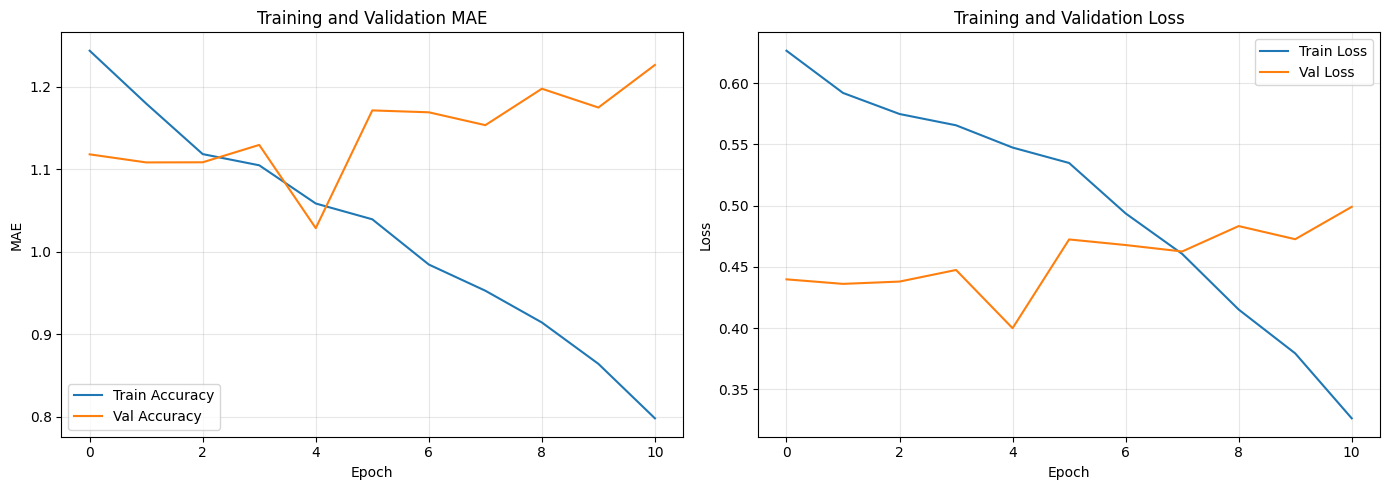

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


<Figure size 640x480 with 0 Axes>

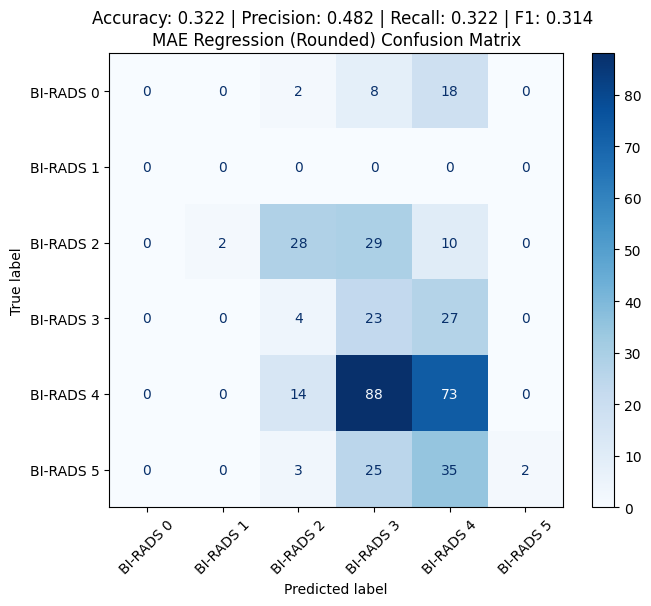

In [55]:
# Visualize training and validation accuracy and loss from Keras history

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_birad_reg.history["mae"], label="Train Accuracy")
plt.plot(history_birad_reg.history["val_mae"], label="Val Accuracy")
plt.title("Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_birad_reg.history["loss"], label="Train Loss")
plt.plot(history_birad_reg.history["val_loss"], label="Val Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# confusion matrix
plt.figure()
y_pred_prob = birad_reg.predict(X_test)
y_pred_cont = np.squeeze(y_pred_prob)
y_pred_cls = np.clip(np.rint(y_pred_cont), 0, 5).astype(int)
y_true_cls = np.clip(np.rint(y_test), 0, 5).astype(int)

labels = [0, 1, 2, 3, 4, 5]
cm = confusion_matrix(y_true_cls, y_pred_cls, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[f"BI-RADS {i}" for i in labels]
)
disp.plot(cmap="Blues", ax=ax, colorbar=True, xticks_rotation=45)

acc = accuracy_score(y_true_cls, y_pred_cls)
prec = precision_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
rec = recall_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
f1 = f1_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)

ax.set_title("MAE Regression (Rounded) Confusion Matrix")
plt.suptitle(f"Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


# map the birad scores to benign vs malignant and redo the confusion matrix. 0 to 3 is benign and 4 to 5 is malignant

In [53]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# from sklearn.model_selection import StratifiedKFold
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import TensorDataset, DataLoader
# import pandas as pd
# import numpy as np

# # -------------------------
# # GPU CHECK
# # -------------------------

# print("Using device: ", device)

# torch.cuda.empty_cache()

# torch.manual_seed(RANDOM_SEED)
# np.random.seed(RANDOM_SEED)

# # -------------------------
# # MODEL
# # -------------------------
# class ShallowCNN(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.features = nn.Sequential(
#             nn.Conv2d(1, 32, kernel_size=3),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(32, 64, kernel_size=3),
#             nn.ReLU(),
#             nn.MaxPool2d(2)
#         )

#         # infer flatten size
#         with torch.no_grad():
#             dummy = torch.zeros(1, 1, IMAGE_SIZE, IMAGE_SIZE)
#             n_flat = self.features(dummy).view(1, -1).shape[1]

#         self.classifier = nn.Sequential(
#             nn.Linear(n_flat, 64),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(64, 1)
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = torch.flatten(x, 1)
#         x = self.classifier(x)
#         return x.squeeze(1)

# # -------------------------
# # DATA
# # imgs expected shape: (N,C,H,W)
# # -------------------------
# X = imgs.float()
# y = pathology_labels.long()

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
# fold_results = []

# for fold, (train_idx, val_idx) in enumerate(skf.split(X.cpu(), y.cpu()), 1):

#     model = ShallowCNN().to(device)

#     criterion = nn.BCEWithLogitsLoss()
#     optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

#     X_train = X[train_idx]
#     y_train = y[train_idx].float()

#     X_val = X[val_idx]
#     y_val = y[val_idx].float()

#     train_ds = TensorDataset(X_train, y_train)
#     train_loader = DataLoader(
#         train_ds,
#         batch_size=BATCH_SIZE,
#         shuffle=True,
#         pin_memory=True
#     )

#     best_auc = -1
#     best_state = None
#     patience = 10
#     wait = 0

#     # -------------------------
#     # TRAIN LOOP
#     # -------------------------
#     for epoch in range(NUM_EPOCHS):
#         model.train()

#         for xb, yb in train_loader:
#             xb = xb.to(device, non_blocking=True)
#             yb = yb.to(device, non_blocking=True)

#             optimizer.zero_grad()
#             logits = model(xb)
#             loss = criterion(logits, yb)
#             loss.backward()
#             optimizer.step()

#         # -------------------------
#         # VALIDATION
#         # -------------------------
#         model.eval()
#         with torch.no_grad():
#             logits = model(X_val.to(device))
#             probs = torch.sigmoid(logits).cpu().numpy()

#         try:
#             val_auc = roc_auc_score(y_val.numpy(), probs)
#         except:
#             val_auc = 0.5

#         print(f"Fold {fold} Epoch {epoch+1}: val_auc={val_auc:.4f}")

#         if val_auc > best_auc:
#             best_auc = val_auc
#             best_state = model.state_dict()
#             wait = 0
#         else:
#             wait += 1
#             if wait >= patience:
#                 print("Early stopping")
#                 break

#     # restore best
#     model.load_state_dict(best_state)

#     # -------------------------
#     # FINAL EVAL
#     # -------------------------
#     model.eval()
#     with torch.no_grad():
#         logits = model(X_val.to(device))
#         val_pred = torch.sigmoid(logits).cpu().numpy()

#     val_cls = (val_pred >= 0.5).astype(int)

#     y_true = y_val.numpy().astype(int)

#     acc = accuracy_score(y_true, val_cls)
#     prec = precision_score(y_true, val_cls, zero_division=0)
#     rec = recall_score(y_true, val_cls, zero_division=0)
#     f1 = f1_score(y_true, val_cls, zero_division=0)
#     auc = roc_auc_score(y_true, val_pred)

#     # Store both validation and training metrics for this fold

#     # Compute training predictions and metrics
#     model.eval()
#     with torch.no_grad():
#         train_logits = model(X_train.to(device))
#         train_pred = torch.sigmoid(train_logits).cpu().numpy()
#     train_cls = (train_pred >= 0.5).astype(int)
#     y_train_true = y_train.cpu().numpy().astype(int)

#     train_acc = accuracy_score(y_train_true, train_cls)
#     train_prec = precision_score(y_train_true, train_cls, zero_division=0)
#     train_rec = recall_score(y_train_true, train_cls, zero_division=0)
#     train_f1 = f1_score(y_train_true, train_cls, zero_division=0)
#     train_auc = roc_auc_score(y_train_true, train_pred)

#     fold_results.append({
#         "fold": fold,
#         "train_accuracy": train_acc,
#         "train_precision": train_prec,
#         "train_recall": train_rec,
#         "train_f1": train_f1,
#         "train_auc": train_auc,
#         "val_accuracy": acc,
#         "val_precision": prec,
#         "val_recall": rec,
#         "val_f1": f1,
#         "val_auc": auc
#     })

#     print(
#         f"Fold {fold}: "
#         f"accuracy={acc:.4f}, precision={prec:.4f}, "
#         f"recall={rec:.4f}, f1={f1:.4f}, auc={auc:.4f}"
#     )

# # -------------------------
# # RESULTS
# # -------------------------
# results_df = pd.DataFrame(fold_results)
# print(results_df)

# print(f"Mean accuracy:  {results_df['accuracy'].mean():.4f}")
# print(f"Mean precision: {results_df['precision'].mean():.4f}")
# print(f"Mean recall:    {results_df['recall'].mean():.4f}")
# print(f"Mean F1:        {results_df['f1'].mean():.4f}")
# print(f"Mean AUC:       {results_df['auc'].mean():.4f}")

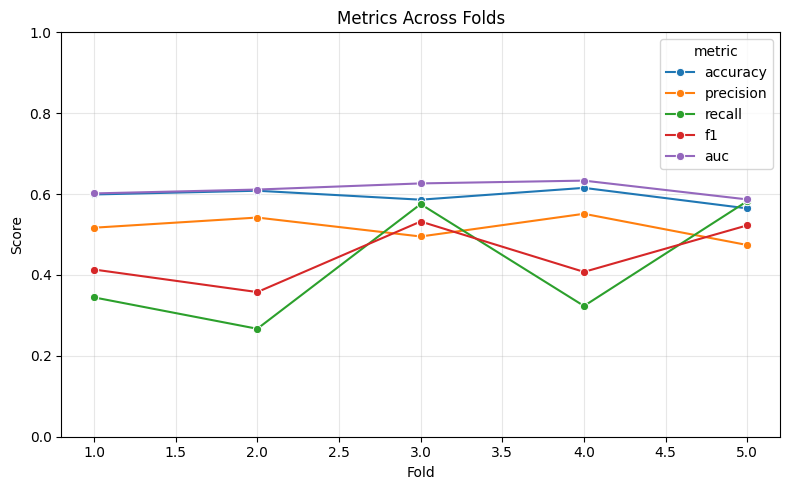

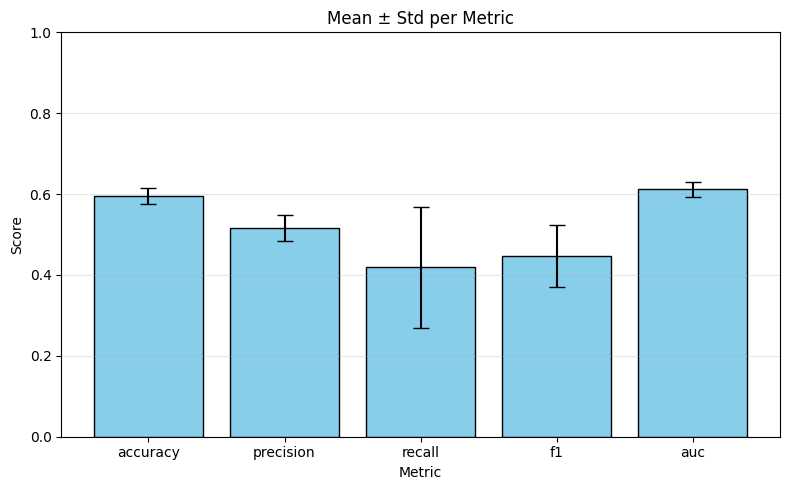

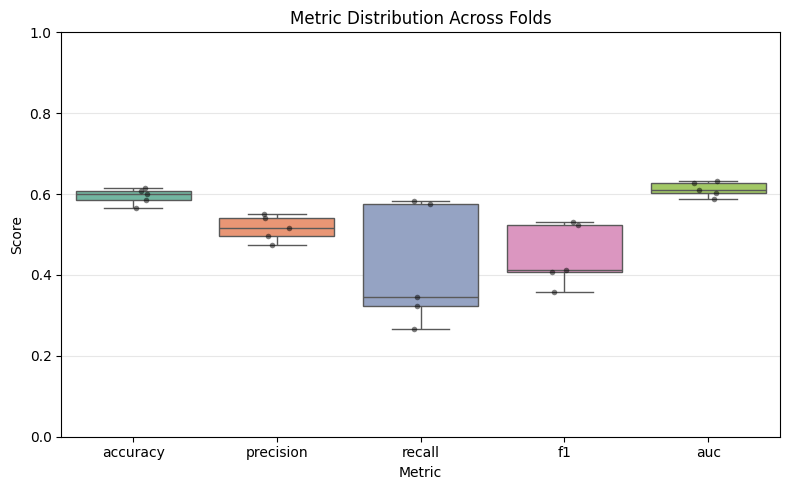

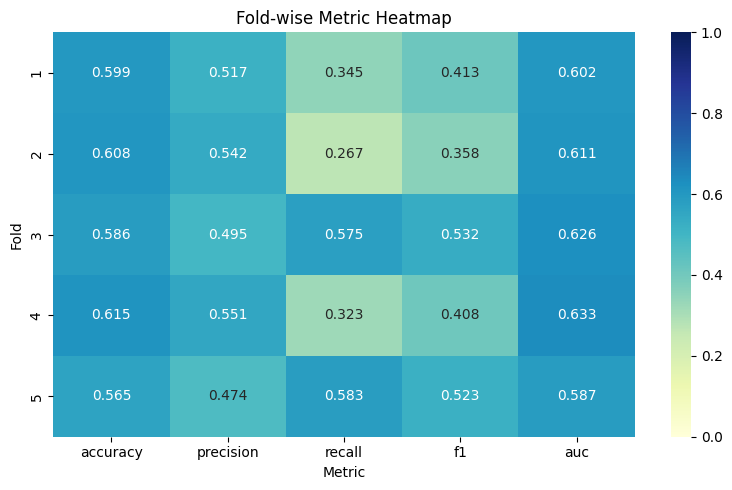

,metric,mean,std
4,auc,0.611876,0.018741
0,accuracy,0.594705,0.020062
1,precision,0.515854,0.032090
3,f1,0.446738,0.076892
2,recall,0.418538,0.149181


In [ ]:
# Visualize all cross-validation metrics stored in results_df, each in its own figure

metrics = [m for m in ["accuracy", "precision", "recall", "f1", "auc"] if m in results_df.columns]
long_df = results_df.melt(id_vars="fold", value_vars=metrics, var_name="metric", value_name="score")

# 1) Metric trend across folds
plt.figure(figsize=(8, 5))
sns.lineplot(data=long_df, x="fold", y="score", hue="metric", marker="o")
plt.title("Metrics Across Folds")
plt.xlabel("Fold")
plt.ylabel("Validation Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Mean ± std by metric
summary = results_df[metrics].agg(["mean", "std"]).T.reset_index().rename(columns={"index": "metric"})
plt.figure(figsize=(8, 5))
plt.bar(summary["metric"], summary["mean"], yerr=summary["std"], capsize=6, color="skyblue", edgecolor="black")
plt.title("Mean ± Std per Metric")
plt.xlabel("Metric")
plt.ylabel("Validation Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Distribution per metric
plt.figure(figsize=(8, 5))
sns.boxplot(data=long_df, x="metric", y="score", palette="Set2")
sns.stripplot(data=long_df, x="metric", y="score", color="black", alpha=0.5, size=4)
plt.title("Metric Distribution Across Folds")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Heatmap: fold x metric
plt.figure(figsize=(8, 5))
heat = results_df.set_index("fold")[metrics]
sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlGnBu", cbar=True, vmin=0, vmax=1)
plt.title("Fold-wise Metric Heatmap")
plt.xlabel("Metric")
plt.ylabel("Fold")
plt.tight_layout()
plt.show()

# Optional compact numeric summary
display(summary.sort_values("mean", ascending=False))

torch.Size([3252, 1, 256, 256])